# Behavioral Analysis
## - evidence of conflicting value maps in States A and B but not C

In [1]:
import h5_utilities_module as h5u
import numpy as np
import pandas as pd
import pingouin as pg
from tqdm import tqdm
from matplotlib import pyplot as plt
import statsmodels.formula.api as smf
import matplotlib.gridspec as gridspec
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import binomtest

In [2]:
# define the directory where the files live
data_dir = r'C:/Users/thome/Documents/PYTHON/OFC-CdN 3 state self control/files_for_decoder/'
data_files = h5u.find_h5_files(data_dir)

In [3]:
# functions
def calculate_mean_and_interval(data, type='sem', num_samples=1000, alpha=0.05):
    """
    Calculate mean and either SEM or bootstrapped CI for input array, disregarding NaN values.
    Works with both 1D and 2D arrays.
    """
    # Ensure data is 2D
    data = np.asarray(data)
    if data.ndim == 1:
        data = data.reshape(-1, 1)
    
    nan_mask = ~np.isnan(data)
    nanmean_result = np.nanmean(data, axis=0)
    n_valid_values = np.sum(nan_mask, axis=0)
    
    if type == 'sem':
        nanstd_result = np.nanstd(data, axis=0)
        interval = nanstd_result / np.sqrt(n_valid_values)
        
    elif type == 'percentile':
        interval = np.nanmean(np.array([
            np.abs(nanmean_result - np.nanpercentile(data, 5, axis=0)),
            np.abs(nanmean_result - np.nanpercentile(data, 95, axis=0))
        ]))
        
    elif type == 'bootstrap':
        n_rows = data.shape[0]
        n_cols = data.shape[1]
        bootstrap_means = np.zeros((num_samples, n_cols))

        for col in range(n_cols):
            valid_data = data[:, col][nan_mask[:, col]]
            if len(valid_data) > 0:
                bootstrap_samples = np.random.choice(valid_data, size=(num_samples, n_rows), replace=True)
                bootstrap_means[:, col] = np.nanmean(bootstrap_samples, axis=1)
            else:
                bootstrap_means[:, col] = np.nan

        ci_lower = np.percentile(bootstrap_means, 100 * (alpha / 2), axis=0)
        ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2), axis=0)
        interval = np.nanmean([
            abs(bootstrap_means - ci_lower),
            abs(bootstrap_means - ci_upper)
        ], axis=0)
        interval = np.nanmean(interval, axis=0)

    else:
        raise ValueError("Invalid 'type' argument. Use 'sem', 'percentile', or 'bootstrap'.")
    
    # Properly handle scalar output
    if data.shape[1] == 1:
        nanmean_result = float(nanmean_result[0])  # explicitly convert to float scalar
        if not np.isscalar(interval):
            interval = float(interval[0])  # explicitly convert to float scalar
    
    return nanmean_result, interval

def check_vif(formula_vars, data):
    X = data[formula_vars].dropna()
    return [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]


def compare_two_proportions(count1, total1, count2, total2):
    """
    Compare two proportions using chi-square test (or Fisher's exact for small counts).
    
    Parameters:
    -----------
    count1, count2 : int
        Number in category for each group
    total1, total2 : int
        Total number for each group
        
    Returns:
    --------
    statistic, p_value, test_name : tuple
    """
    # Create 2x2 contingency table
    contingency = np.array([
        [count1, count2],
        [total1 - count1, total2 - count2]
    ])
    
    # Use Fisher's exact for small expected counts, chi-square otherwise
    expected = contingency.sum(axis=1, keepdims=True) * contingency.sum(axis=0, keepdims=True) / contingency.sum()
    
    if np.any(expected < 5):
        # Fisher's exact test
        odds_ratio, p_value = fisher_exact(contingency)
        return odds_ratio, p_value, "Fisher's exact"
    else:
        # Chi-square test
        chi2, p_value, dof, expected = chi2_contingency(contingency)
        return chi2, p_value, "Chi-square"
    
    
def chi2_contingency(observed):
    """
    Perform chi-square test of independence on a contingency table.
    
    Parameters:
    -----------
    observed : array-like
        Contingency table (2D array) of observed frequencies
        
    Returns:
    --------
    chi2 : float
        The chi-square test statistic
    p_value : float
        The p-value of the test
    dof : int
        Degrees of freedom
    expected : ndarray
        Expected frequencies based on marginal sums
    """
    observed = np.asarray(observed)
    
    # Calculate row and column totals
    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    total = observed.sum()
    
    # Calculate expected frequencies
    expected = (row_totals * col_totals) / total
    
    # Calculate chi-square statistic
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        chi2 = np.sum((observed - expected)**2 / expected)
    
    # Calculate degrees of freedom
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)
    
    # Calculate p-value using chi-square distribution
    from scipy.stats import chi2 as chi2_dist
    p_value = 1 - chi2_dist.cdf(chi2, dof)
    
    return chi2, p_value, dof, expected


def get_ch_and_unch_vals(bhv):
    """
    Extracts chosen (ch_val) and unchosen (unch_val) values associated with each trial.

    Parameters:
    - bhv (DataFrame): DataFrame behavioral data.

    Returns:
    - ch_val (ndarray): Array of chosen values for each trial.
    - unch_val (ndarray): Array of unchosen values for each trial. 
                          - places 0s for unchosen values on forced choice trials
    """
    ch_val = np.zeros(shape=(len(bhv, )))
    unch_val = np.zeros(shape=(len(bhv, )))

    bhv['r_val'] = bhv['r_val'].fillna(0)
    bhv['l_val'] = bhv['l_val'].fillna(0)

    ch_left = bhv['side'] == -1
    ch_right = bhv['side'] == 1

    ch_val[ch_left] = bhv['l_val'].loc[ch_left].astype(int)
    ch_val[ch_right] = bhv['r_val'].loc[ch_right].astype(int)

    unch_val[ch_left] = bhv['r_val'].loc[ch_left].astype(int)
    unch_val[ch_right] = bhv['l_val'].loc[ch_right].astype(int)

    return ch_val, unch_val

In [4]:
# loop over the files and accumulate the behavioral data

# initialize a dataframe
bhv = pd.DataFrame()

for this_file in tqdm(data_files):
    
    # pull this file's behavior
    f_data = pd.read_hdf(this_file, key='bhv')

    # Append the data to the accumulated dataframe
    bhv = pd.concat([bhv, f_data], ignore_index=True)


100%|██████████| 8/8 [00:00<00:00, 104.64it/s]


In [5]:
# create indices to separately analyze each monkey
k_ix = bhv['fname'].str.contains('K')
d_ix = bhv['fname'].str.contains('D')
bhv['subject'] = np.where(k_ix, 0, 1)
bhv['delta_val'] = bhv['r_val'] - bhv['l_val']
ch_val, unch_val = get_ch_and_unch_vals(bhv)

In [6]:
double_take = bhv['n_sacc'] == 2

np.mean(double_take[(bhv['forced'] == 0) & (bhv['sacc1_side'] == -1) & d_ix])

0.2555301296720061

In [7]:
# get overall choice accuracies
k_acc = bhv['picked_best'].loc[k_ix].mean()
d_acc = bhv['picked_best'].loc[d_ix].mean()

print('subject K accuracy: ' + str(k_acc*100))
print('subject D accuracy: ' + str(d_acc*100))

subject K accuracy: 98.81312543635094
subject D accuracy: 97.78645833333334


In [8]:
# find the identities of the value differences
val_diff = bhv['l_val'] - bhv['r_val']
val_diff_ids = np.unique(val_diff[~np.isnan(val_diff)])
# find the trials where the monkey picked the left option

picked_left = (bhv['side'] == -1).to_numpy().astype(int).reshape((-1, 1))
rt = bhv['rt'].values.reshape((-1,1))
n_sacc = bhv['n_sacc'].values.reshape(-1,1)

# we're only going to assess the free choices
free_ix = bhv['forced'] == 0

# initialize arrays to accumulate results into
# choice accuracy
choice_acc_mean = np.zeros((3, len(val_diff_ids), 2)) # 3 states, n_val_diffs, 2 monkeys
choice_acc_ci = np.zeros((3, len(val_diff_ids), 2)) # 3 states, n_val_diffs, 2 monkeys

# choice reaction time
choice_rt_mean = np.zeros((3, len(val_diff_ids), 2)) # 3 states, n_val_diffs, 2 monkeys
choice_rt_ci = np.zeros((3, len(val_diff_ids), 2)) # 3 states, n_val_diffs, 2 monkeys


# loop over the val_diff_ids and get the mean for each value difference and state
for v_num, v_id in enumerate(val_diff_ids):

    # find the trials associated with this value difference
    v_ix = val_diff == v_id

    # take the means and 95% CIs
    choice_acc_mean[0, v_num, 0], choice_acc_ci[0, v_num, 0] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 1) & k_ix], 'bootstrap')
    choice_acc_mean[1, v_num, 0], choice_acc_ci[1, v_num, 0] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 2) & k_ix], 'bootstrap')
    choice_acc_mean[2, v_num, 0], choice_acc_ci[2, v_num, 0] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 3) & k_ix], 'bootstrap')

    choice_acc_mean[0, v_num, 1], choice_acc_ci[0, v_num, 1] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 1) & d_ix], 'bootstrap')
    choice_acc_mean[1, v_num, 1], choice_acc_ci[1, v_num, 1] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 2) & d_ix], 'bootstrap')
    choice_acc_mean[2, v_num, 1], choice_acc_ci[2, v_num, 1] = calculate_mean_and_interval(picked_left[free_ix & v_ix & (bhv['state'] == 3) & d_ix], 'bootstrap')

    choice_rt_mean[0, v_num, 0], choice_rt_ci[0, v_num, 0] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 1) & k_ix], 'bootstrap')
    choice_rt_mean[1, v_num, 0], choice_rt_ci[1, v_num, 0] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 2) & k_ix], 'bootstrap')
    choice_rt_mean[2, v_num, 0], choice_rt_ci[2, v_num, 0] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 3) & k_ix], 'bootstrap')

    choice_rt_mean[0, v_num, 1], choice_rt_ci[0, v_num, 1] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 1) & d_ix], 'bootstrap')
    choice_rt_mean[1, v_num, 1], choice_rt_ci[1, v_num, 1] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 2) & d_ix], 'bootstrap')
    choice_rt_mean[2, v_num, 1], choice_rt_ci[2, v_num, 1] = calculate_mean_and_interval(rt[free_ix & v_ix & (bhv['state'] == 3) & d_ix], 'bootstrap')

c:\Users\thome\anaconda3\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\thome\anaconda3\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
C:\Users\thome\AppData\Local\Temp\ipykernel_50252\3891016745.py:41: RuntimeWarning: Mean of empty slice
  interval = np.nanmean([
C:\Users\thome\AppData\Local\Temp\ipykernel_50252\3891016745.py:45: RuntimeWarning: Mean of empty slice
  interval = np.nanmean(interval, axis=0)
C:\Users\thome\AppData\Local\Temp\ipykernel_50252\3891016745.py:13: RuntimeWarning: Mean of empty slice
  nanmean_result = np.nanmean(data, axis=0)


In [9]:
# find the value of the item the animals first saccaded towards on double-take trials
single_take_ix = (bhv['n_sacc'] == 1) & free_ix
double_take_ix = (bhv['n_sacc'] == 2) & free_ix

# initialize an array to accumulate results into
first_sacc_mean = np.zeros((4, 2)) 
first_sacc_ci = np.zeros((4, 2)) 


# get the values fixated on double takes
sacc1_vals = bhv['sacc1_val'].values.reshape(-1,1)

# calculate means and confidence intervals
first_sacc_mean[0,0], first_sacc_ci[0,0] = calculate_mean_and_interval(sacc1_vals[single_take_ix & k_ix & (bhv['state']<3)], 'bootstrap')
first_sacc_mean[1,0], first_sacc_ci[1,0] = calculate_mean_and_interval(sacc1_vals[double_take_ix & k_ix & (bhv['state']<3)], 'bootstrap')
first_sacc_mean[2,0], first_sacc_ci[2,0] = calculate_mean_and_interval(sacc1_vals[single_take_ix & k_ix & (bhv['state']==3)], 'bootstrap')
first_sacc_mean[3,0], first_sacc_ci[3,0] = calculate_mean_and_interval(sacc1_vals[double_take_ix & k_ix & (bhv['state']==3)], 'bootstrap')


first_sacc_mean[0,1], first_sacc_ci[0,1] = calculate_mean_and_interval(sacc1_vals[single_take_ix & d_ix & (bhv['state']<3)], 'bootstrap')
first_sacc_mean[1,1], first_sacc_ci[1,1] = calculate_mean_and_interval(sacc1_vals[double_take_ix & d_ix & (bhv['state']<3)], 'bootstrap')
first_sacc_mean[2,1], first_sacc_ci[2,1] = calculate_mean_and_interval(sacc1_vals[single_take_ix & d_ix & (bhv['state']==3)], 'bootstrap')
first_sacc_mean[3,1], first_sacc_ci[3,1] = calculate_mean_and_interval(sacc1_vals[double_take_ix & d_ix & (bhv['state']==3)], 'bootstrap')


(0.0, 3.0)

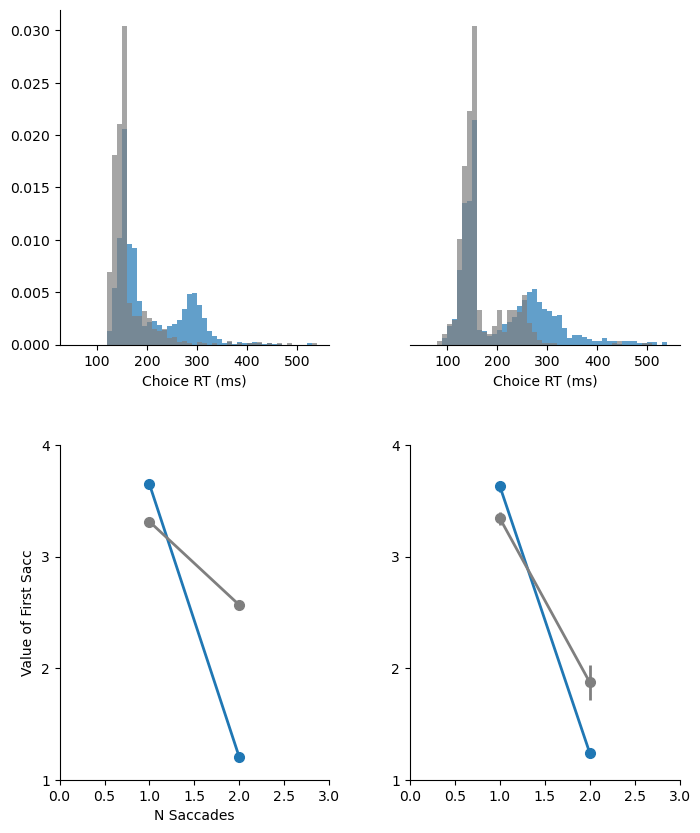

In [10]:
# now let's plot

fig, ax = plt.subplots(2, 2, figsize=(8,10))
# Adjust space between subplots
fig.subplots_adjust(wspace=0.3, hspace=.3)  # add some white space between the plots

# define bins for the histogram
bins = np.arange(50, 550, 10)

# plot King's data

# choice RT histograms
ax[0,0].hist(bhv['rt'].loc[k_ix & (bhv['state'] <3) & free_ix], bins=bins, density='probability', alpha = .7, color='tab:blue')
ax[0,0].hist(bhv['rt'].loc[k_ix & (bhv['state'] == 3) & free_ix], bins=bins, density='probability', alpha = .7, color='tab:gray')
ax[0,0].set_xlabel('Choice RT (ms)')
ax[0,0].spines['right'].set_visible(False)
ax[0,0].spines['top'].set_visible(False)
ax[0,0].set_xticks((100, 200, 300, 400, 500))


# value of first saccade by state and number of saccades
ax[1,0].errorbar([1,2], first_sacc_mean[0:2, 0], first_sacc_ci[0:2, 0], color='tab:blue', marker='o', ms = 7, lw=2)
ax[1,0].errorbar([1,2], first_sacc_mean[2:4, 0], first_sacc_ci[0:2, 0], color='tab:gray', marker='o', ms = 7, lw=2)
ax[1,0].spines['right'].set_visible(False)
ax[1,0].spines['top'].set_visible(False)
ax[1,0].set_xlabel('N Saccades')
ax[1,0].set_xlim((0,3))
ax[1,0].set_ylabel('Value of First Sacc')
ax[1,0].set_ylim((1, 4))
ax[1,0].set_yticks((1, 2, 3, 4))




# Don

# choice RT histograms
ax[0,1].hist(bhv['rt'].loc[d_ix & (bhv['state'] <3) & free_ix], bins=bins, density='probability', alpha = .7, color='tab:blue')
ax[0,1].hist(bhv['rt'].loc[d_ix & (bhv['state'] == 3) & free_ix], bins=bins, density='probability', alpha = .7, color='tab:gray')
ax[0,1].set_xlabel('Choice RT (ms)')
ax[0,1].spines['right'].set_visible(False)
ax[0,1].spines['left'].set_visible(False)
ax[0,1].spines['top'].set_visible(False)
ax[0,1].set_yticks(())
ax[0,1].set_xticks((100, 200, 300, 400, 500))

# value of first saccade by state and number of saccades
ax[1,1].errorbar([1,2], first_sacc_mean[0:2, 1], first_sacc_ci[0:2, 1], color='tab:blue', marker='o', ms = 7, lw = 2)
ax[1,1].errorbar([1,2], first_sacc_mean[2:4, 1], first_sacc_ci[2:4, 1], color='tab:gray', marker='o', ms = 7, lw = 2)
ax[1,1].spines['right'].set_visible(False)
ax[1,1].spines['top'].set_visible(False)
ax[1,1].set_ylim((1, 4))
ax[1,1].set_yticks((1, 2, 3, 4))
ax[1,1].set_xlim((0,3))

# save the figure as a png
#plt.savefig("DTs_and_vals.svg")


In [11]:
# build the dataframe
sacc_df = pd.DataFrame()

sacc_df['session'] = np.concatenate((
    bhv['fname'].loc[single_take_ix & (bhv['state']<3)].values,
    bhv['fname'].loc[double_take_ix & (bhv['state']<3)].values,
    bhv['fname'].loc[single_take_ix & (bhv['state']==3)].values,
    bhv['fname'].loc[double_take_ix & (bhv['state']==3)].values
), axis=0).flatten()

monkey_ix = np.concatenate((
    k_ix[single_take_ix & (bhv['state']<3)],
    k_ix[double_take_ix & (bhv['state']<3)],
    k_ix[single_take_ix & (bhv['state']==3)],
    k_ix[double_take_ix & (bhv['state']==3)]
), axis=0).flatten() > 0

sacc_df['sacc_val'] = np.concatenate((
    sacc1_vals[single_take_ix & (bhv['state']<3)],
    sacc1_vals[double_take_ix & (bhv['state']<3)],
    sacc1_vals[single_take_ix & (bhv['state']==3)],
    sacc1_vals[double_take_ix & (bhv['state']==3)]
), axis=0).flatten().astype(int)

sacc_df['n_sacc'] = np.concatenate((
    np.zeros(np.sum(single_take_ix & (bhv['state']<3))),
    np.ones(np.sum(double_take_ix & (bhv['state']<3))),
    np.zeros(np.sum(single_take_ix & (bhv['state']==3))),
    np.ones(np.sum(double_take_ix & (bhv['state']==3)))
), axis=0)

sacc_df['state'] = np.concatenate((
    np.zeros(np.sum(single_take_ix & (bhv['state']<3))),
    np.zeros(np.sum(double_take_ix & (bhv['state']<3))),
    np.ones(np.sum(single_take_ix & (bhv['state']==3))),
    np.ones(np.sum(double_take_ix & (bhv['state']==3)))
), axis=0)

# fit mixed effects models with session as random effect, separately per subject
k_data = sacc_df.loc[monkey_ix == 1].copy()
d_data = sacc_df.loc[monkey_ix == 0].copy()

k_sacc_model = smf.mixedlm(
    'sacc_val ~ n_sacc * state',
    data=k_data,
    groups=k_data['session']
).fit()

d_sacc_model = smf.mixedlm(
    'sacc_val ~ n_sacc * state',
    data=d_data,
    groups=d_data['session']
).fit()

print('Subject K')
print(k_sacc_model.summary())
print('\nSubject D')
print(d_sacc_model.summary())

Subject K
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sacc_val  
No. Observations: 2505    Method:             REML      
No. Groups:       4       Scale:              0.4029    
Min. group size:  563     Log-Likelihood:     -2424.3825
Max. group size:  664     Converged:          Yes       
Mean group size:  626.2                                 
--------------------------------------------------------
             Coef.  Std.Err.    z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     3.647    0.021 170.624 0.000  3.605  3.689
n_sacc       -2.447    0.033 -73.961 0.000 -2.512 -2.382
state        -0.335    0.029 -11.431 0.000 -0.392 -0.277
n_sacc:state  1.697    0.138  12.270 0.000  1.426  1.968
Group Var     0.000    0.001                            


Subject D
         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sacc_val  
No. Observations: 2149    Met

c:\Users\thome\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\thome\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [12]:
bhv['chose_right'] = (bhv['side'] == 1).astype(int)

trials2use = bhv['rt'] < 500

k_val_model = smf.logit('chose_right ~ delta_val + C(state, Sum)',
    data=bhv.loc[k_ix & free_ix & trials2use]).fit(disp=0)

d_val_model = smf.logit('chose_right ~ delta_val + C(state, Sum)',
    data=bhv.loc[d_ix & free_ix & trials2use]).fit(disp=0)

print('Subject K')
print(k_val_model.summary())
print('\nSubject D')
print(d_val_model.summary())

Subject K
                           Logit Regression Results                           
Dep. Variable:            chose_right   No. Observations:                 2586
Model:                          Logit   Df Residuals:                     2582
Method:                           MLE   Df Model:                            3
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                  0.8688
Time:                        15:34:06   Log-Likelihood:                -235.10
converged:                       True   LL-Null:                       -1792.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                0.0901      0.137      0.655      0.512      -0.179       0.360
C(state, Sum)[S.1.0]    -0.0606      0.193     -0.314      0.753      -0.439       0.318
C(

In [13]:
print(k_val_model.params.index.tolist())

['Intercept', 'C(state, Sum)[S.1.0]', 'C(state, Sum)[S.2.0]', 'delta_val']


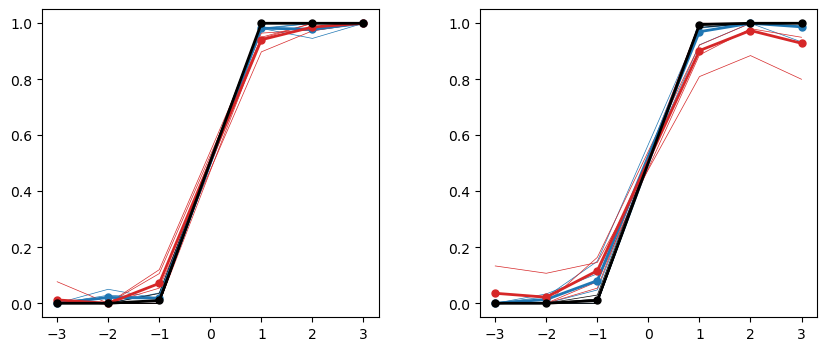

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.subplots_adjust(wspace=0.3)
state_colors = {1: 'tab:red', 2: 'tab:blue', 3: 'tab:green'}
state_labels = {1: 'State A', 2: 'State B', 3: 'State C'}
val_diff_levels = [-3, -2, -1, 1, 2, 3]
subs = np.unique(bhv['subject'])
choose_right = (bhv['side'] == 1).values

# loop over monkeys
for s_ix, s in enumerate(subs):
    this_monkey_sessions = np.unique(bhv['fname'].loc[bhv['subject'] == s])

    # pre-allocate arrays for this subject's grand mean
    grand_state_means = np.zeros(shape = (3, len(val_diff_levels)))

    # pre-allocate arrays for the session means
    sessions_state_means = np.zeros(shape = (3, len(val_diff_levels), len(this_monkey_sessions)))


    # now get the grand mean results for this subject
    # loop over the states
    for state_ix, this_state in enumerate(np.unique(bhv['state'])):

        # now loop over the value differences
        for v_ix, delta_val in enumerate(val_diff_levels):

            # index the trials which correspond to this state-value-subject combination
            this_state_val = (bhv['subject'] == s) & (bhv['state'] == this_state) & (bhv['delta_val'] == delta_val) & free_ix & (bhv['rt'] < 500)
            grand_state_means[state_ix, v_ix] = np.nanmean(choose_right[this_state_val])


            # now get the means for each session
            for session_ix, this_session in enumerate(this_monkey_sessions):

                this_session_ix = bhv['fname'] == this_session

                sessions_state_means[state_ix, v_ix, session_ix] = np.nanmean(choose_right[this_state_val & this_session_ix])

    # now plot for this monkey
    axes[s_ix].plot(val_diff_levels, sessions_state_means[0,:,:], color = 'tab:blue', lw = .5)
    axes[s_ix].plot(val_diff_levels, sessions_state_means[1,:,:], color = 'tab:red', lw = .5)
    axes[s_ix].plot(val_diff_levels, sessions_state_means[2,:,:], color = 'black', lw = .5)


    axes[s_ix].plot(val_diff_levels, grand_state_means[0, :], color = 'tab:blue', lw = 2, marker='o', markersize = 5)
    axes[s_ix].plot(val_diff_levels, grand_state_means[1, :], color = 'tab:red', lw = 2, marker='o', markersize = 5)
    axes[s_ix].plot(val_diff_levels, grand_state_means[2, :], color = 'black', lw = 2, marker='o', markersize = 5)

# now let's save the plot
#fig.savefig('choice-accuracy-by-state.svg')





In [15]:
# find the liklihood of a double-take as a function of each left/right choice

val_ids = np.arange(1,5,1)
n_vals = len(val_ids)

state_AB_ix = bhv['state'] < 3
state_C_ix = bhv['state'] == 3

dt = bhv['n_sacc'] > 1

pDT_by_val_and_state = np.zeros((n_vals, n_vals, 2, 2)) # each left-right value combination, 2 states, 2 monkeys
pDT_by_val_and_state[:] = np.nan

# loop over each combination of left and right values
for l_ix, l_val in enumerate(val_ids):
    for r_ix, r_val in enumerate(val_ids):

        val_combi_ix = (bhv['l_val'] == l_val) & (bhv['r_val'] == r_val)

        if r_val != l_val:
            pDT_by_val_and_state[l_ix, r_ix, 0, 0] = np.nanmean(dt[val_combi_ix & free_ix & k_ix & state_AB_ix], axis=0)
            pDT_by_val_and_state[l_ix, r_ix, 1, 0] = np.nanmean(dt[val_combi_ix & free_ix & k_ix & state_C_ix], axis=0)

            pDT_by_val_and_state[l_ix, r_ix, 0, 1] = np.nanmean(dt[val_combi_ix & free_ix & d_ix & state_AB_ix], axis=0)
            pDT_by_val_and_state[l_ix, r_ix, 1, 1] = np.nanmean(dt[val_combi_ix & free_ix & d_ix & state_C_ix], axis=0)

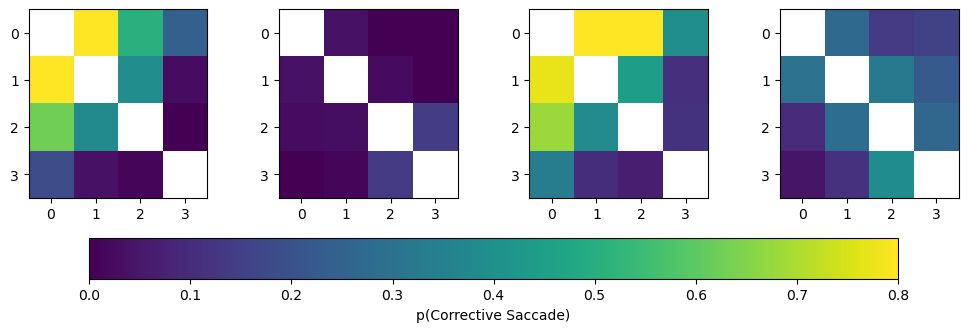

In [16]:
# show mean RTs and mean n_sacc for all trial conditions separately
fig, ax = plt.subplots(1, 4, figsize=(12, 3.5))
fig.subplots_adjust(wspace=0.4, hspace=.4)  # add some white space between the plots
p_min = 0
p_max = .8

# organized as:
# subject as column pairs (leftmost is subj K's RTs, then K's n_sacc, then D's RTs, then D's n_sacc)
im0 = ax[0].imshow(pDT_by_val_and_state[:,:,0, 0], aspect='auto', vmin=p_min, vmax=p_max)
im1 = ax[1].imshow(pDT_by_val_and_state[:,:,1, 0], aspect='auto', vmin=p_min, vmax=p_max)
im2 = ax[2].imshow(pDT_by_val_and_state[:,:,0, 1], aspect='auto', vmin=p_min, vmax=p_max)
im3 = ax[3].imshow(pDT_by_val_and_state[:,:,1, 1], aspect='auto', vmin=p_min, vmax=p_max)

# Add a single colorbar shared for all RT plots
fig.colorbar(im0, ax=ax, orientation='horizontal', label='p(Corrective Saccade)')

#plt.show()
#plt.savefig("probDT_by_cond.svg")




In [17]:
# find the proportion of all double-takes occurring in each left/right choice condition
val_ids = np.arange(1,5,1)
n_vals = len(val_ids)
state_AB_ix = (bhv['state'] < 3).values
state_C_ix = (bhv['state'] == 3).values
dt = bhv['n_sacc'] == 2

# total double-takes per monkey per state, for normalizing
k_total = np.sum(dt & k_ix & free_ix)
d_total = np.sum(dt & d_ix & free_ix)
k_AB_total = np.sum(dt & k_ix & free_ix & state_AB_ix)
k_C_total  = np.sum(dt & k_ix & free_ix & state_C_ix)
d_AB_total = np.sum(dt & d_ix & free_ix & state_AB_ix)
d_C_total  = np.sum(dt & d_ix & free_ix & state_C_ix)

# proportion of double-takes in each left/right value combination
prop_DT_by_val_and_state = np.full((n_vals, n_vals, 2, 2), fill_value=np.nan)

for l_ix, l_val in enumerate(val_ids):
    for r_ix, r_val in enumerate(val_ids):
        val_combi_ix = ((bhv['l_val'] == l_val) & (bhv['r_val'] == r_val)).values
        if r_val != l_val:
            prop_DT_by_val_and_state[l_ix, r_ix, 0, 0] = np.sum(dt & val_combi_ix & free_ix & k_ix & state_AB_ix) 
            prop_DT_by_val_and_state[l_ix, r_ix, 1, 0] = np.sum(dt & val_combi_ix & free_ix & k_ix & state_C_ix)  
            prop_DT_by_val_and_state[l_ix, r_ix, 0, 1] = np.sum(dt & val_combi_ix & free_ix & d_ix & state_AB_ix) 
            prop_DT_by_val_and_state[l_ix, r_ix, 1, 1] = np.sum(dt & val_combi_ix & free_ix & d_ix & state_C_ix)  

In [18]:
double_takes_with1 = np.sum(prop_DT_by_val_and_state[:,1])# proportion of double-takes that occurred when value 1 was present in the trial
# value 1 is present when either l_val == 1 or r_val == 1
val1_ix = ((bhv['l_val'] == 1) | (bhv['r_val'] == 1)).values

# sum across all l/r combinations where value 1 was present
# (equivalent to summing the relevant rows/cols of prop_DT_by_val_and_state)
k_AB_val1 = np.sum(dt & val1_ix & free_ix & k_ix & state_AB_ix) / k_total
d_AB_val1 = np.sum(dt & val1_ix & free_ix & d_ix & state_AB_ix) / d_total

print(f'Subject K {k_AB_val1:.1%} of double-takes involved value 1')
print(f'Subject D {d_AB_val1:.1%} of double-takes involved value 1')


Subject K 77.5% of double-takes involved value 1
Subject D 65.9% of double-takes involved value 1


In [19]:
k_total

570

In [20]:
np.sum(dt & free_ix & k_ix & state_AB_ix)# / k_total

547

In [21]:
np.sum(val1_ix & free_ix & k_ix & state_AB_ix) / np.sum(free_ix & k_ix)

0.3384223918575064

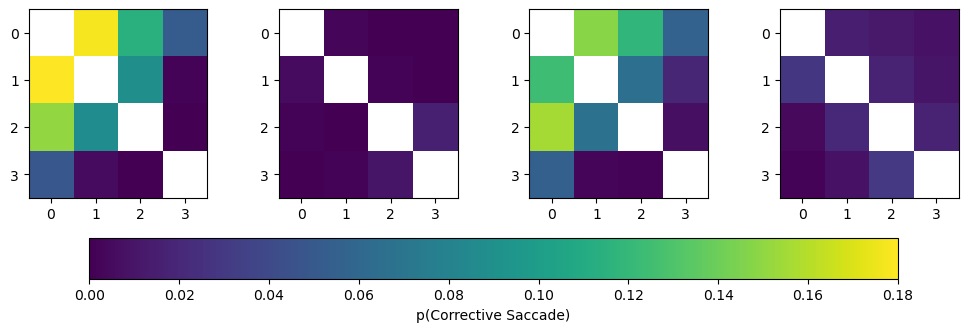

In [22]:
# show mean RTs and mean n_sacc for all trial conditions separately
fig, ax = plt.subplots(1, 4, figsize=(12, 3.5))
fig.subplots_adjust(wspace=0.4, hspace=.4)  # add some white space between the plots
p_min = 0
p_max = .18

# organized as:
# subject as column pairs (leftmost is subj K's RTs, then K's n_sacc, then D's RTs, then D's n_sacc)
im0 = ax[0].imshow(prop_DT_by_val_and_state[:,:,0, 0] / k_total, aspect='auto', vmin=p_min, vmax=p_max)
im1 = ax[1].imshow(prop_DT_by_val_and_state[:,:,1, 0] / k_total, aspect='auto', vmin=p_min, vmax=p_max)
im2 = ax[2].imshow(prop_DT_by_val_and_state[:,:,0, 1] / d_total, aspect='auto', vmin=p_min, vmax=p_max)
im3 = ax[3].imshow(prop_DT_by_val_and_state[:,:,1, 1] / d_total, aspect='auto', vmin=p_min, vmax=p_max)

# Add a single colorbar shared for all RT plots
fig.colorbar(im0, ax=ax, orientation='horizontal', label='p(Corrective Saccade)')

#plt.savefig("probDT_by_cond.svg")

In [23]:
# fit models assessing why corrective saccades occur
# use all free choice trials across all states
all_free_ix = free_ix
reg_df = bhv.loc[all_free_ix].copy()

# create indices to keep track of the animal
k_ix_reg = reg_df['fname'].str.contains('K')
d_ix_reg = reg_df['fname'].str.contains('D')

# create indices for the states
stateAB_ix = reg_df['state'] < 3
stateC_ix = reg_df['state'] == 3

# dummy code state: 1 for states A and B, -1 for state C
reg_df['state_AB'] = np.where(reg_df['state'] < 3, 1, -1)

# define the counterfactual values of the options (only meaningful for states A and B)
reg_df['l_val_counter'] = np.where(reg_df['state'] < 3, 5 - reg_df['l_val'], np.nan)
reg_df['r_val_counter'] = np.where(reg_df['state'] < 3, 5 - reg_df['r_val'], np.nan)

# define cross-state conflict such that larger numbers indicate the counterfactual value is better
reg_df['conflict_L'] = np.where(reg_df['state'] < 3, reg_df['l_val_counter'] - reg_df['l_val'], 0)
reg_df['conflict_R'] = np.where(reg_df['state'] < 3, reg_df['r_val_counter'] - reg_df['r_val'], 0)

# define summary conflict terms and outcome variables
reg_df['real_val_diff'] = np.abs(reg_df['l_val'] - reg_df['r_val'])
reg_df['conflict_sum']  = reg_df['conflict_L'] + reg_df['conflict_R']
# candidate alternative predictors for model comparison
reg_df['max_val'] = reg_df[['l_val', 'r_val']].max(axis=1)
reg_df['sum_val'] = reg_df['l_val'] + reg_df['r_val']
reg_df['AB_val_diff']   = np.where(reg_df['state_AB'] ==  1, reg_df['real_val_diff'], 0)
reg_df['C_val_diff']    = np.where(reg_df['state_AB'] == -1, reg_df['real_val_diff'], 0)
reg_df['corrective_sacc'] = (reg_df['n_sacc'] > 1).astype(int)

reg_df['subject'] = np.where(reg_df['fname'].str.contains('K'), 1, -1)

reg_df['val_diff_z'] = (reg_df['real_val_diff'] - reg_df['real_val_diff'].mean()) / reg_df['real_val_diff'].std()
reg_df['state_AB_z'] = (reg_df['state_AB'] - reg_df['state_AB'].mean()) / reg_df['state_AB'].std()

# add trial history (run length) as a regressor
# recompute run_length_capped aligned to reg_df's index
run_length_all = np.ones(len(bhv), dtype=int)
sessions_all = bhv['fname'].values
state_all = bhv['state'].values
for t in range(1, len(bhv)):
    if sessions_all[t] == sessions_all[t-1] and state_all[t] == state_all[t-1]:
        run_length_all[t] = run_length_all[t-1] + 1
run_length_capped_all = np.minimum(run_length_all, 3)
reg_df['trial_history'] = run_length_capped_all[all_free_ix]


In [24]:
# check the variance inflation factors of possible candidate models
# - can we include real_val_diff and max_val in the same model?
# ANSWER - no

model_comparisons = [
    ('conflict + val_diff', ['conflict_sum', 'real_val_diff']),
    ('conflict + max_val', ['conflict_sum', 'max_val']),
    ('conflict + val_diff + max_val', ['conflict_sum', 'real_val_diff', 'max_val']),
    ('val_diff + max_val', ['real_val_diff', 'max_val']),
    ('conflict + trial_history', ['conflict_sum', 'trial_history']),
    ('val_diff + trial_history', ['real_val_diff', 'trial_history']),
    ('conflict + val_diff + trial_history', ['conflict_sum', 'real_val_diff', 'trial_history']),
]

vif_rows = []
for subj, ix in zip(['K', 'D'], [k_ix_reg, d_ix_reg]):
    data = reg_df.loc[ix & stateAB_ix]
    for model_name, vars in model_comparisons:
        vifs = check_vif(vars, data)
        for var, vif in zip(vars, vifs):
            vif_rows.append({
                'Subject': subj,
                'Model': model_name,
                'Predictor': var,
                'VIF': round(vif, 2)
            })

vif_df = pd.DataFrame(vif_rows)
print(vif_df.to_string(index=False))

Subject                               Model     Predictor   VIF
      K                 conflict + val_diff  conflict_sum  1.00
      K                 conflict + val_diff real_val_diff  1.00
      K                  conflict + max_val  conflict_sum  1.03
      K                  conflict + max_val       max_val  1.03
      K       conflict + val_diff + max_val  conflict_sum  1.37
      K       conflict + val_diff + max_val real_val_diff 10.75
      K       conflict + val_diff + max_val       max_val 11.12
      K                  val_diff + max_val real_val_diff  8.10
      K                  val_diff + max_val       max_val  8.10
      K            conflict + trial_history  conflict_sum  1.00
      K            conflict + trial_history trial_history  1.00
      K            val_diff + trial_history real_val_diff  3.22
      K            val_diff + trial_history trial_history  3.22
      K conflict + val_diff + trial_history  conflict_sum  1.00
      K conflict + val_diff + trial_hist

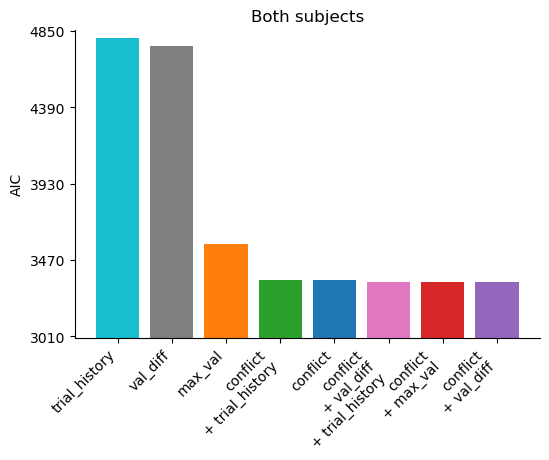

In [25]:
# Does conflict improve prediction of corrective saccades over and above other value parameters?
data_AB = reg_df.loc[stateAB_ix].copy()

# formulas = {
#     'val_diff':                    'corrective_sacc ~ real_val_diff + subject',
#     'max_val':                     'corrective_sacc ~ max_val + subject',
#     'conflict':                    'corrective_sacc ~ conflict_sum + subject',
#     'trial_history':               'corrective_sacc ~ trial_history + subject',
#     'conflict\n+ val_diff':        'corrective_sacc ~ conflict_sum + real_val_diff + subject',
#     'conflict\n+ max_val':         'corrective_sacc ~ conflict_sum + max_val + subject',
#     'conflict\n+ trial_history':   'corrective_sacc ~ conflict_sum + trial_history + subject',
#     'conflict\n+ val_diff\n+ trial_history': 'corrective_sacc ~ conflict_sum + real_val_diff + trial_history + subject',
# }


formulas = {
    'val_diff':                    'corrective_sacc ~ real_val_diff',
    'max_val':                     'corrective_sacc ~ max_val',
    'conflict':                    'corrective_sacc ~ conflict_sum',
    'trial_history':               'corrective_sacc ~ trial_history',
    'conflict\n+ val_diff':        'corrective_sacc ~ conflict_sum + real_val_diff',
    'conflict\n+ max_val':         'corrective_sacc ~ conflict_sum + max_val',
    'conflict\n+ trial_history':   'corrective_sacc ~ conflict_sum + trial_history',
    'conflict\n+ val_diff\n+ trial_history': 'corrective_sacc ~ conflict_sum + real_val_diff + trial_history',
}

models = {}
aics = {}
for label, formula in formulas.items():
    model = smf.logit(formula, data=data_AB).fit(disp=0)
    models[label] = model
    aics[label] = model.aic

# plot
model_labels = list(formulas.keys())
colors = ['tab:gray', 'tab:orange', 'tab:blue', 'tab:cyan', 'tab:purple', 'tab:red', 'tab:green', 'tab:pink']

vals = [aics[label] for label in model_labels]

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
order = np.argsort(vals)[::-1]
sorted_labels = [model_labels[j] for j in order]
sorted_vals = [vals[j] for j in order]
sorted_colors = [colors[j] for j in order]
ax.bar(sorted_labels, sorted_vals, color=sorted_colors)
ymin = min(sorted_vals) * 0.9
ymax = max(sorted_vals) * 1.01
tick_min = int(np.ceil(ymin / 10) * 10)
tick_max = int(np.floor(ymax / 10) * 10)
yticks = np.round(np.linspace(tick_min, tick_max, 5) / 10) * 10
ax.set_ylim(ymin, ymax)
ax.set_yticks(yticks)
ax.set_title('Both subjects')
ax.set_ylabel('AIC')
ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
#plt.savefig('model-comparion-AICs.svg')

In [26]:
for subj, subj_ix in zip(['K', 'D'], [k_ix_reg, d_ix_reg]):
    subj_data = reg_df.loc[subj_ix & stateAB_ix].copy()
    mdl = smf.logit('corrective_sacc ~ conflict_sum + real_val_diff', data=subj_data).fit(disp=0)
    print(f'=== Subject {subj} ===')
    print(mdl.summary())
    print()

=== Subject K ===
                           Logit Regression Results                           
Dep. Variable:        corrective_sacc   No. Observations:                 1860
Model:                          Logit   Df Residuals:                     1857
Method:                           MLE   Df Model:                            2
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                  0.3629
Time:                        15:34:07   Log-Likelihood:                -766.45
converged:                       True   LL-Null:                       -1203.0
Covariance Type:            nonrobust   LLR p-value:                2.534e-190
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -0.3523      0.169     -2.085      0.037      -0.683      -0.021
conflict_sum      0.7505      0.037     20.505      0.000       0.679       0.822
real_val_diff    -0.38

In [27]:
data_all = reg_df.loc[free_ix].copy()

# standardize predictors before computing interaction
data_all['val_diff_z'] = (data_all['real_val_diff'] - data_all['real_val_diff'].mean()) / data_all['real_val_diff'].std()
data_all['state_AB_z'] = (data_all['state_AB'] - data_all['state_AB'].mean()) / data_all['state_AB'].std()

# fit the model with interaction
model_partb = smf.logit('corrective_sacc ~ val_diff_z * state_AB_z + C(subject)', 
                         data=data_all).fit(disp=0)
print(model_partb.summary())

                           Logit Regression Results                           
Dep. Variable:        corrective_sacc   No. Observations:                 5306
Model:                          Logit   Df Residuals:                     5301
Method:                           MLE   Df Model:                            4
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:                 0.09775
Time:                        15:34:07   Log-Likelihood:                -2948.6
converged:                       True   LL-Null:                       -3268.1
Covariance Type:            nonrobust   LLR p-value:                5.957e-137
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -0.6719      0.046    -14.497      0.000      -0.763      -0.581
C(subject)[T.1]          -0.6249      0.063     -9.868      0.000      -0.749      -0.501
val_diff

In [28]:
# data_all = reg_df.loc[free_ix & state_AB_ix].copy()

# # fit pooled model
# model_partb = smf.logit('corrective_sacc ~ real_val_diff * state_AB + subject', 
#                          data=data_all).fit(disp=0)
# print('=== Pooled ===')
# print(model_partb.summary())

# # fit separately per subject
# for subj, subj_ix in zip(['K', 'D'], [k_ix_reg, d_ix_reg]):
#     subj_data = data_all.loc[subj_ix].copy()
    
#     subj_model = smf.logit('corrective_sacc ~ real_val_diff * state_AB', 
#                             data=subj_data).fit(disp=0)
#     print(f'\n=== Subject {subj} ===')
#     print(subj_model.summary())

Text(0, 0.5, 'Coefficient')

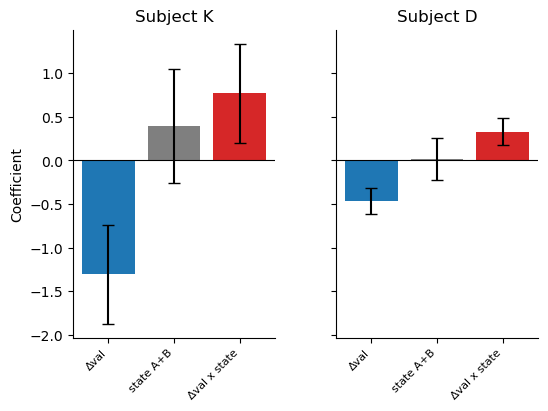

In [29]:
# fit per-subject models first
subj_models = {}
for subj, subj_ix in zip(['K', 'D'], [k_ix_reg, d_ix_reg]):
    subj_data = reg_df.loc[free_ix & subj_ix].copy()
    subj_models[subj] = smf.logit('corrective_sacc ~ real_val_diff * state_AB', 
                                   data=subj_data).fit(disp=0)

# plot
terms = ['real_val_diff', 'state_AB', 'real_val_diff:state_AB']
labels_e = ['Δval', 'state A+B', 'Δval x state']
colors_e = ['tab:blue', 'tab:gray', 'tab:red']

fig, ax = plt.subplots(1, 2, figsize=(6, 4), sharey=True)
fig.subplots_adjust(wspace=0.3)

for s_ix, (subj, model) in enumerate(subj_models.items()):
    coefs = [model.params[t] for t in terms]
    ci_low = [model.conf_int().loc[t, 0] for t in terms]
    ci_high = [model.conf_int().loc[t, 1] for t in terms]
    yerr_low = [coefs[i] - ci_low[i] for i in range(len(terms))]
    yerr_high = [ci_high[i] - coefs[i] for i in range(len(terms))]

    ax[s_ix].bar(labels_e, coefs, color=colors_e)
    ax[s_ix].errorbar(labels_e, coefs,
                      yerr=[yerr_low, yerr_high],
                      fmt='none', color='black', capsize=4)
    ax[s_ix].axhline(0, color='black', linewidth=0.8)
    ax[s_ix].set_title(f'Subject {subj}')
    ax[s_ix].set_xticks((0, 1, 2))
    ax[s_ix].set_xticklabels(labels_e, rotation=45, ha='right', fontsize=8)
    ax[s_ix].spines['right'].set_visible(False)
    ax[s_ix].spines['top'].set_visible(False)

ax[0].set_ylabel('Coefficient')

# plt.savefig('within-state-val-coeffs-by-subject.svg')

In [30]:
val_diff_levels = [1, 2, 3]
diff_colors = ['tab:blue', 'tab:green', 'tab:orange']
conflict_sum_levels = reg_df.loc[stateAB_ix, 'conflict_sum'].unique()
conflict_sum_levels = np.sort(conflict_sum_levels)

C:\Users\thome\AppData\Local\Temp\ipykernel_50252\2633359154.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  beta_ax.set_xticklabels(term_labels, rotation=45, ha='right', fontsize=8)


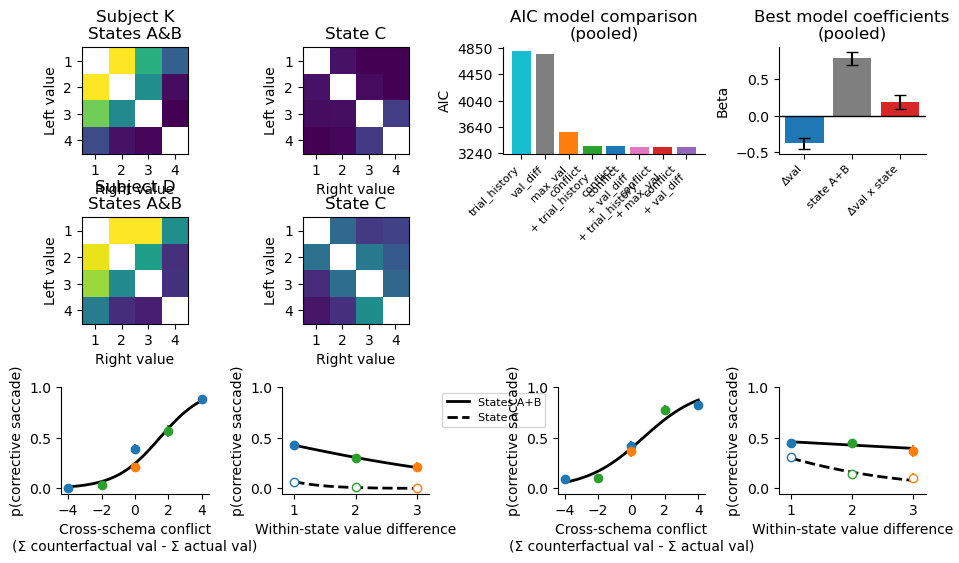

In [31]:
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(4, 20, figure=fig, hspace=0.6, wspace=0.5)

# heatmaps - subject K (row 0)
K_heatmap_AB_ax = fig.add_subplot(gs[0, 0:3])
K_heatmap_C_ax  = fig.add_subplot(gs[0, 4:7])
# AIC and beta weights - pooled, row 0 only, next to K heatmaps
aic_ax          = fig.add_subplot(gs[0, 8:12])
beta_ax         = fig.add_subplot(gs[0, 13:16])
# heatmaps - subject D (row 1)
D_heatmap_AB_ax = fig.add_subplot(gs[1, 0:3])
D_heatmap_C_ax  = fig.add_subplot(gs[1, 4:7])

# regression plots 
K_reg_conf_ax   = fig.add_subplot(gs[2, 0:3])
K_reg_val_ax    = fig.add_subplot(gs[2, 4:7])
D_reg_conf_ax   = fig.add_subplot(gs[2, 9:12])
D_reg_val_ax    = fig.add_subplot(gs[2, 13:16])

# --- heatmaps ---
p_min, p_max = 0, 0.8

K_heatmap_AB_ax.imshow(pDT_by_val_and_state[:,:,0,0], aspect='equal', vmin=p_min, vmax=p_max)
K_heatmap_AB_ax.set_xticks(range(4)); K_heatmap_AB_ax.set_xticklabels([1,2,3,4])
K_heatmap_AB_ax.set_yticks(range(4)); K_heatmap_AB_ax.set_yticklabels([1,2,3,4])
K_heatmap_AB_ax.set_title('Subject K\nStates A&B')
K_heatmap_AB_ax.set_xlabel('Right value')
K_heatmap_AB_ax.set_ylabel('Left value')

K_heatmap_C_ax.imshow(pDT_by_val_and_state[:,:,1,0], aspect='equal', vmin=p_min, vmax=p_max)
K_heatmap_C_ax.set_xticks(range(4)); K_heatmap_C_ax.set_xticklabels([1,2,3,4])
K_heatmap_C_ax.set_yticks(range(4)); K_heatmap_C_ax.set_yticklabels([1,2,3,4])
K_heatmap_C_ax.set_title('State C')
K_heatmap_C_ax.set_xlabel('Right value')
K_heatmap_C_ax.set_ylabel('Left value')

D_heatmap_AB_ax.imshow(pDT_by_val_and_state[:,:,0,1], aspect='equal', vmin=p_min, vmax=p_max)
D_heatmap_AB_ax.set_xticks(range(4)); D_heatmap_AB_ax.set_xticklabels([1,2,3,4])
D_heatmap_AB_ax.set_yticks(range(4)); D_heatmap_AB_ax.set_yticklabels([1,2,3,4])
D_heatmap_AB_ax.set_title('Subject D\nStates A&B')
D_heatmap_AB_ax.set_xlabel('Right value')
D_heatmap_AB_ax.set_ylabel('Left value')

D_heatmap_C_ax.imshow(pDT_by_val_and_state[:,:,1,1], aspect='equal', vmin=p_min, vmax=p_max)
D_heatmap_C_ax.set_xticks(range(4)); D_heatmap_C_ax.set_xticklabels([1,2,3,4])
D_heatmap_C_ax.set_yticks(range(4)); D_heatmap_C_ax.set_yticklabels([1,2,3,4])
D_heatmap_C_ax.set_title('State C')
D_heatmap_C_ax.set_xlabel('Right value')
D_heatmap_C_ax.set_ylabel('Left value')

# --- AIC plot (pooled, panel D) ---
model_labels_aic = list(formulas.keys())
vals_aic = [aics[label] for label in model_labels_aic]
order_aic = np.argsort(vals_aic)[::-1]
sorted_labels_aic = [model_labels_aic[j] for j in order_aic]
sorted_vals_aic = [vals_aic[j] for j in order_aic]
sorted_colors_aic = [colors[j] for j in order_aic]

aic_ax.bar(sorted_labels_aic, sorted_vals_aic, color=sorted_colors_aic)
ymin = min(sorted_vals_aic) * 0.97
ymax = max(sorted_vals_aic) * 1.01
tick_min = int(np.ceil(ymin / 10) * 10)
tick_max = int(np.floor(ymax / 10) * 10)
aic_ax.set_yticks(np.round(np.linspace(tick_min, tick_max, 5) / 10) * 10)
aic_ax.set_ylim(ymin, ymax)
aic_ax.set_title('AIC model comparison\n(pooled)')
aic_ax.set_ylabel('AIC')
aic_ax.set_xticks(range(len(sorted_labels_aic)))
aic_ax.set_xticklabels(sorted_labels_aic, rotation=45, ha='right', fontsize=8)
aic_ax.spines['right'].set_visible(False)
aic_ax.spines['top'].set_visible(False)

# --- beta weights (pooled, panel E) ---
terms = ['val_diff_z', 'state_AB_z', 'val_diff_z:state_AB_z']
term_labels = ['Δval', 'state A+B', 'Δval x state']
beta_colors = ['tab:blue', 'tab:gray', 'tab:red']

coefs = [model_partb.params[t] for t in terms]
ci_low = [model_partb.conf_int().loc[t, 0] for t in terms]
ci_high = [model_partb.conf_int().loc[t, 1] for t in terms]
yerr_low = [coefs[i] - ci_low[i] for i in range(len(terms))]
yerr_high = [ci_high[i] - coefs[i] for i in range(len(terms))]

beta_ax.bar(term_labels, coefs, color=beta_colors)
beta_ax.errorbar(term_labels, coefs,
                 yerr=[yerr_low, yerr_high],
                 fmt='none', color='black', capsize=4)
beta_ax.axhline(0, color='k', lw=1)
beta_ax.set_ylabel('Beta')
beta_ax.set_title('Best model coefficients\n(pooled)')
beta_ax.set_xticklabels(term_labels, rotation=45, ha='right', fontsize=8)
beta_ax.spines['right'].set_visible(False)
beta_ax.spines['top'].set_visible(False)

# --- regression plots ---
conflict_sum_fine = np.linspace(-4, 4, 100)
val_diff_fine = np.linspace(1, 3, 100)

for subj, k_or_d, conf_ax, val_ax in zip(
    ['K', 'D'],
    [k_ix_reg, d_ix_reg],
    [K_reg_conf_ax, D_reg_conf_ax],
    [K_reg_val_ax, D_reg_val_ax]
):
    AB_df = reg_df.loc[k_or_d & stateAB_ix]
    all_df = reg_df.loc[k_or_d & free_ix]

    # fit per-subject models
    subj_model_conf = smf.logit('corrective_sacc ~ conflict_sum + real_val_diff', data=AB_df).fit(disp=0)
    subj_model_val  = smf.logit('corrective_sacc ~ val_diff_z * state_AB_z', data=all_df).fit(disp=0)

    # z-score means for this subject's data
    mean_state_AB_z_AB = all_df.loc[all_df['state_AB'] == 1, 'state_AB_z'].mean()
    mean_state_AB_z_C  = all_df.loc[all_df['state_AB'] == -1, 'state_AB_z'].mean()
    val_diff_mean = all_df['real_val_diff'].mean()
    val_diff_std  = all_df['real_val_diff'].std()
    val_diff_fine_z = (val_diff_fine - val_diff_mean) / val_diff_std

    # conflict panel - observed data
    for vd, color in zip(val_diff_levels, diff_colors):
        for conf in conflict_sum_levels:
            mask = (AB_df['real_val_diff'] == vd) & (AB_df['conflict_sum'] == conf)
            if mask.sum() < 3:
                continue
            m, ci = calculate_mean_and_interval(AB_df.loc[mask, 'corrective_sacc'].values.reshape(-1,1), 'bootstrap')
            conf_ax.errorbar(conf, m, ci, color=color, marker='o', ms=6, lw=0, elinewidth=1.5)

    # conflict panel - model fit
    pred_conf_df = pd.DataFrame({
        'real_val_diff': np.full(100, np.mean(val_diff_levels)),
        'conflict_sum': conflict_sum_fine,
    })
    conf_ax.plot(conflict_sum_fine, subj_model_conf.predict(pred_conf_df), color='k', lw=2)
    conf_ax.set_xlabel('Cross-schema conflict\n(Σ counterfactual val - Σ actual val)')
    conf_ax.set_ylabel('p(corrective saccade)')
    conf_ax.set_ylim(-0.05, 1)
    conf_ax.set_xticks([-4, -2, 0, 2, 4])
    conf_ax.spines['right'].set_visible(False)
    conf_ax.spines['top'].set_visible(False)

    # val diff panel - observed data
    for state, filled in [(1, True), (-1, False)]:
        state_df = reg_df.loc[k_or_d & (reg_df['state_AB'] == state)]
        for vd, color in zip(val_diff_levels, diff_colors):
            mask = state_df['real_val_diff'] == vd
            if mask.sum() < 3:
                continue
            m, ci = calculate_mean_and_interval(state_df.loc[mask, 'corrective_sacc'].values.reshape(-1,1), 'bootstrap')
            val_ax.errorbar(vd, m, ci, color=color, marker='o', ms=6, lw=0, elinewidth=1.5,
                            markerfacecolor=color if filled else 'white', markeredgecolor=color)

    # val diff panel - model fit
    pred_AB = pd.DataFrame({
        'val_diff_z': val_diff_fine_z,
        'state_AB_z': np.full(100, mean_state_AB_z_AB),
    })
    pred_C = pd.DataFrame({
        'val_diff_z': val_diff_fine_z,
        'state_AB_z': np.full(100, mean_state_AB_z_C),
    })
    val_ax.plot(val_diff_fine, subj_model_val.predict(pred_AB), color='k', lw=2, label='States A+B')
    val_ax.plot(val_diff_fine, subj_model_val.predict(pred_C), color='k', lw=2, ls='--', label='State C')
    val_ax.set_xlabel('Within-state value difference')
    val_ax.set_ylabel('p(corrective saccade)')
    val_ax.set_ylim(-0.05, 1)
    val_ax.set_xlim(0.8, 3.2)
    val_ax.spines['right'].set_visible(False)
    val_ax.spines['top'].set_visible(False)
    if subj == 'K':
        val_ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

c:\Users\thome\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\thome\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\thome\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\thome\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\thome\anaconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\thome

=== Subject K ===
                            OLS Regression Results                            
Dep. Variable:                     rt   R-squared:                       0.277
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     339.3
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          1.72e-125
Time:                        15:46:27   Log-Likelihood:                -10315.
No. Observations:                1776   AIC:                         2.064e+04
Df Residuals:                    1773   BIC:                         2.065e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept       254.5980    

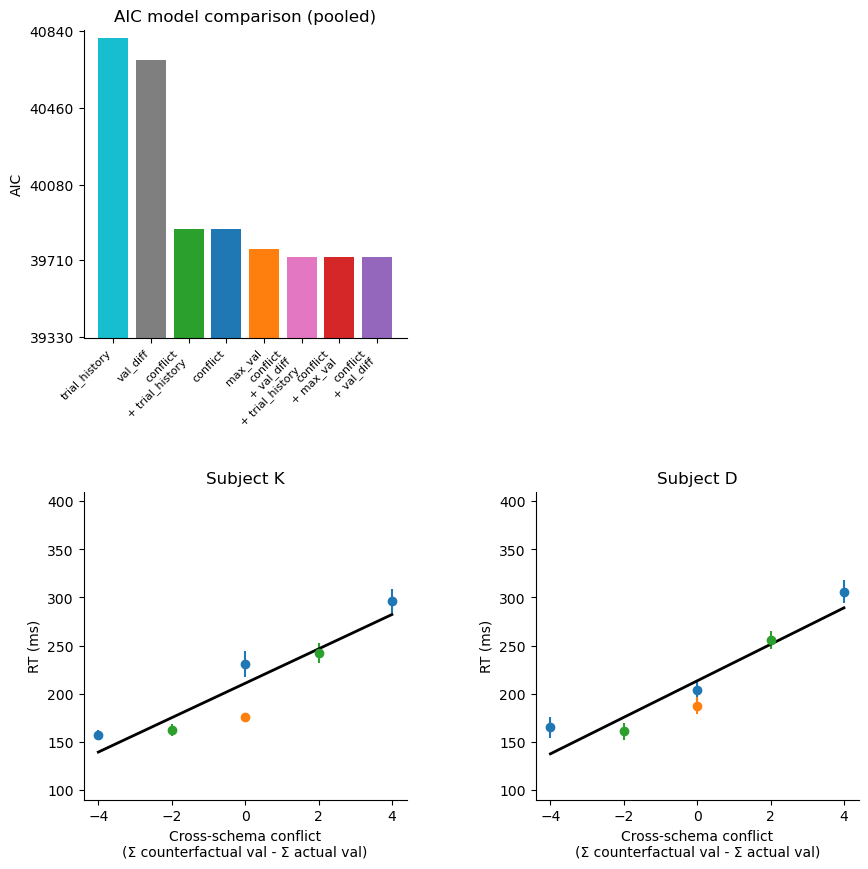

In [38]:
# --- RT model comparison ---

# formulas 
rt_formulas = {
    'val_diff':                    'rt ~ real_val_diff',
    'max_val':                     'rt ~ max_val',
    'conflict':                    'rt ~ conflict_sum',
    'trial_history':               'rt ~ trial_history',
    'conflict\n+ val_diff':        'rt ~ conflict_sum + real_val_diff',
    'conflict\n+ max_val':         'rt ~ conflict_sum + max_val',
    'conflict\n+ trial_history':   'rt ~ conflict_sum + trial_history',
    'conflict\n+ val_diff\n+ trial_history': 'rt ~ conflict_sum + real_val_diff + trial_history',
}

val_diff_levels = [1, 2, 3]
diff_colors = ['tab:blue', 'tab:green', 'tab:orange']
colors = ['tab:gray', 'tab:orange', 'tab:blue', 'tab:cyan', 'tab:purple', 'tab:red', 'tab:green', 'tab:pink']

# prepare data and fit pooled models
data_stateAB_rt = reg_df.loc[stateAB_ix, ['rt', 'real_val_diff', 'conflict_sum', 'max_val', 'trial_history', 'subject']].dropna().copy().reset_index(drop=True)

rt_models = {}
rt_aics = {}
for label, formula in rt_formulas.items():
    model = smf.mixedlm(formula, data=data_stateAB_rt, groups=data_stateAB_rt['subject'].values).fit(reml=False)
    rt_models[label] = model
    rt_aics[label] = model.aic

# prediction grids
conflict_sum_fine = np.linspace(-4, 4, 100)
mean_val_diff_rt = data_stateAB_rt['real_val_diff'].mean()
conflict_sum_levels = np.sort(reg_df.loc[stateAB_ix, 'conflict_sum'].unique())

# --- figure ---
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.4)

# --- AIC plot (top left) ---
rt_model_labels = list(rt_formulas.keys())
vals_aic = [rt_aics[label] for label in rt_model_labels]
order_aic = np.argsort(vals_aic)[::-1]
sorted_labels_aic = [rt_model_labels[j] for j in order_aic]
sorted_vals_aic   = [vals_aic[j] for j in order_aic]
sorted_colors_aic = [colors[j] for j in order_aic]

ax[0,0].bar(sorted_labels_aic, sorted_vals_aic, color=sorted_colors_aic)
ymin = min(sorted_vals_aic) * 0.99
ymax = max(sorted_vals_aic) * 1.001
tick_min = int(np.ceil(ymin / 10) * 10)
tick_max = int(np.floor(ymax / 10) * 10)
ax[0,0].set_yticks(np.round(np.linspace(tick_min, tick_max, 5) / 10) * 10)
ax[0,0].set_ylim(ymin, ymax)
ax[0,0].set_title('AIC model comparison (pooled)')
ax[0,0].set_ylabel('AIC')
ax[0,0].set_xticks(range(len(sorted_labels_aic)))
ax[0,0].set_xticklabels(sorted_labels_aic, rotation=45, ha='right', fontsize=8)
ax[0,0].spines['right'].set_visible(False)
ax[0,0].spines['top'].set_visible(False)

# hide top right
ax[0,1].axis('off')

# --- conflict regression plots (bottom row) ---
for subj, k_or_d, conf_ax in zip(
    ['K', 'D'],
    [k_ix_reg, d_ix_reg],
    [ax[1,0], ax[1,1]]
):
    AB_df = reg_df.loc[k_or_d & stateAB_ix]

    # fit per-subject model
    subj_model_conf = smf.ols('rt ~ conflict_sum + real_val_diff', data=AB_df.dropna(subset=['rt'])).fit()
    print(f'=== Subject {subj} ===')
    print(subj_model_conf.summary())
    print()

    # observed data
    for vd, color in zip(val_diff_levels, diff_colors):
        for conf in conflict_sum_levels:
            mask = (AB_df['real_val_diff'] == vd) & (AB_df['conflict_sum'] == conf) & AB_df['rt'].notna()
            if mask.sum() < 3:
                continue
            m, ci = calculate_mean_and_interval(AB_df.loc[mask, 'rt'].values.reshape(-1,1), 'bootstrap')
            conf_ax.errorbar(conf, m, ci, color=color, marker='o', ms=6, lw=0, elinewidth=1.5)

    # model fit line
    pred_conf_df = pd.DataFrame({
        'real_val_diff': np.full(100, mean_val_diff_rt),
        'conflict_sum':  conflict_sum_fine,
    })
    conf_ax.plot(conflict_sum_fine, subj_model_conf.predict(pred_conf_df), color='k', lw=2)
    conf_ax.set_xlabel('Cross-schema conflict\n(Σ counterfactual val - Σ actual val)')
    conf_ax.set_ylabel('RT (ms)')
    conf_ax.set_xticks([-4, -2, 0, 2, 4])
    conf_ax.set_ylim((90, 410))
    conf_ax.set_title(f'Subject {subj}')
    conf_ax.spines['right'].set_visible(False)
    conf_ax.spines['top'].set_visible(False)

#fig.savefig('RT_model_comparison.svg')

In [ ]:
double_take_ix = bhv['n_sacc'] == 2

k_nR_corrective_saccs = np.sum(k_ix & double_take_ix & (bhv['sacc1_side'] == 1))
k_nL_corrective_saccs = np.sum(k_ix & double_take_ix & (bhv['sacc1_side'] == -1))

d_nR_corrective_saccs = np.sum(d_ix & double_take_ix & (bhv['sacc1_side'] == 1))
d_nL_corrective_saccs = np.sum(d_ix & double_take_ix & (bhv['sacc1_side'] == -1))


In [ ]:
d_nR_corrective_saccs + d_nL_corrective_saccs

In [ ]:
k_nR_corrective_saccs / (k_nR_corrective_saccs + k_nL_corrective_saccs)

In [ ]:
d_nR_corrective_saccs / (d_nR_corrective_saccs + d_nL_corrective_saccs)

In [ ]:
binomtest(k_nL_corrective_saccs, k_nR_corrective_saccs + k_nL_corrective_saccs, p=0.5)

In [ ]:
binomtest(d_nL_corrective_saccs, d_nR_corrective_saccs + d_nL_corrective_saccs, p=0.5)

In [ ]:
# --- History effect: run length x transition type ---
# For each trial, identify what state transition just occurred (previous state -> current state)
# and how many consecutive trials the monkey has been in the current state

max_run = 3

state = bhv['state'].values
n_sacc = bhv['n_sacc'].values
sessions = bhv['fname'].values
dt = (n_sacc == 2).astype(float)

# compute run lengths and track previous state, per session
run_length = np.ones(len(bhv), dtype=int)
prev_state = np.full(len(bhv), np.nan)

for t in range(1, len(bhv)):
    if sessions[t] == sessions[t-1]:
        if state[t] == state[t-1]:
            run_length[t] = run_length[t-1] + 1
            prev_state[t] = prev_state[t-1]  # carry forward the previous state
        else:
            run_length[t] = 1
            prev_state[t] = state[t-1]  # this is a transition trial
    else:
        run_length[t] = 1
        prev_state[t] = np.nan  # session boundary — no valid previous state

run_length_capped = np.minimum(run_length, max_run)

# define all transition types
transitions = [(1,2), (1,3), (2,1), (2,3), (3,1), (3,2)]
transition_labels = ['A→B', 'A→C', 'B→A', 'B→C', 'C→A', 'C→B']
n_transitions = len(transitions)

stateAB_free_ix = ((bhv['state'] < 3) & free_ix).values

# initialize arrays: (n_transitions, max_run, 2 subjects)
pDT_by_run_trans      = np.full((n_transitions, max_run, 2), np.nan)
pDT_by_run_trans_ci   = np.full((n_transitions, max_run, 2), np.nan)

for t_ix, (prev, curr) in enumerate(transitions):
    trans_ix = (prev_state == prev) & (state == curr)
    for r_ix, r in enumerate(range(1, max_run + 1)):
        run_ix = run_length_capped == r
        trials_k = trans_ix & run_ix & free_ix.values & k_ix.values
        trials_d = trans_ix & run_ix & free_ix.values & d_ix.values
        if np.sum(trials_k) > 0:
            pDT_by_run_trans[t_ix, r_ix, 0], pDT_by_run_trans_ci[t_ix, r_ix, 0] = \
                calculate_mean_and_interval(dt[trials_k], 'bootstrap')
        if np.sum(trials_d) > 0:
            pDT_by_run_trans[t_ix, r_ix, 1], pDT_by_run_trans_ci[t_ix, r_ix, 1] = \
                calculate_mean_and_interval(dt[trials_d], 'bootstrap')


# plot: two subplots (one per monkey), all transition types overlaid
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
plt.subplots_adjust(wspace=0.3)

xt = np.arange(1, max_run + 1)
subj_labels = ['Subject K', 'Subject D']

# use a colormap to distinguish transition types
trans_colors = plt.cm.tab10(np.linspace(0, 0.6, n_transitions))

for s_ix in range(2):
    for t_ix, label in enumerate(transition_labels):
        ax[s_ix].errorbar(xt, pDT_by_run_trans[t_ix, :, s_ix],
                          pDT_by_run_trans_ci[t_ix, :, s_ix],
                          marker='o', color=trans_colors[t_ix],
                          linestyle='-', markersize=5, label=label)
    ax[s_ix].set_title(subj_labels[s_ix], fontsize=9)
    ax[s_ix].set_xticks(xt)
    ax[s_ix].set_ylim(0, 1)
    ax[s_ix].set_xlabel('Consecutive trials in current state', fontsize=8)
    ax[s_ix].spines['right'].set_visible(False)
    ax[s_ix].spines['top'].set_visible(False)

ax[0].set_ylabel('p(corrective saccade)', fontsize=8)
ax[1].legend(fontsize=7, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.suptitle('p(corrective saccade) by transition type and run length', fontsize=10)
plt.tight_layout()
plt.show()

=== Subject K ===
                           Logit Regression Results                           
Dep. Variable:                     dt   No. Observations:                 2751
Model:                          Logit   Df Residuals:                     2749
Method:                           MLE   Df Model:                            1
Date:                Fri, 03 Apr 2026   Pseudo R-squ.:               0.0001430
Time:                        16:26:16   Log-Likelihood:                -1403.4
converged:                       True   LL-Null:                       -1403.6
Covariance Type:            nonrobust   LLR p-value:                    0.5264
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.4052      0.110    -12.723      0.000      -1.622      -1.189
run_length     0.0443      0.070      0.636      0.525      -0.092       0.181

=== Subject D ===
               

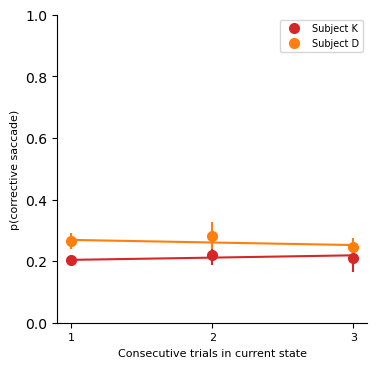

In [40]:
max_run = 3

# --- compute run lengths and previous state per session ---
state = bhv['state'].values
n_sacc = bhv['n_sacc'].values
sessions = bhv['fname'].values
dt = (n_sacc == 2).astype(float)

run_length = np.ones(len(bhv), dtype=int)
prev_state = np.full(len(bhv), np.nan)

for t in range(1, len(bhv)):
    if sessions[t] == sessions[t-1]:
        if state[t] == state[t-1]:
            run_length[t] = run_length[t-1] + 1
            prev_state[t] = prev_state[t-1]
        else:
            run_length[t] = 1
            prev_state[t] = state[t-1]
    else:
        run_length[t] = 1
        prev_state[t] = np.nan

run_length_capped = np.minimum(run_length, max_run)

# --- fit per-subject logistic regressions ---
def logistic(x): return 1 / (1 + np.exp(-x))

xt_fit = np.linspace(1, max_run, 100)
subj_fits = {}

for subj, subj_ix, subj_label in zip([0, 1], [k_ix, d_ix], ['K', 'D']):
    run_df = pd.DataFrame({
        'dt':         dt[free_ix.values & subj_ix.values],
        'run_length': run_length_capped[free_ix.values & subj_ix.values],
    }).dropna()
    
    mdl = smf.logit('dt ~ run_length', run_df).fit(disp=0)
    print(f'=== Subject {subj_label} ===')
    print(mdl.summary())
    print()
    
    subj_fits[subj_label] = logistic(mdl.params['Intercept'] + mdl.params['run_length'] * xt_fit)

# --- compute means and CIs per run length ---
pDT_by_run    = np.full((max_run, 2), np.nan)
pDT_by_run_ci = np.full((max_run, 2), np.nan)

for r_ix, r in enumerate(range(1, max_run + 1)):
    run_ix = run_length_capped == r
    pDT_by_run[r_ix, 0], pDT_by_run_ci[r_ix, 0] = calculate_mean_and_interval(dt[run_ix & free_ix.values & k_ix.values], 'bootstrap')
    pDT_by_run[r_ix, 1], pDT_by_run_ci[r_ix, 1] = calculate_mean_and_interval(dt[run_ix & free_ix.values & d_ix.values], 'bootstrap')

# --- plot ---
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
xt       = np.arange(1, max_run + 1)
xtlabels = ['1', '2', '3']

ax.errorbar(xt, pDT_by_run[:, 0], pDT_by_run_ci[:, 0],
            marker='o', color='tab:red', linestyle='none', markersize=7, label='Subject K')
ax.errorbar(xt, pDT_by_run[:, 1], pDT_by_run_ci[:, 1],
            marker='o', color='tab:orange', linestyle='none', markersize=7, label='Subject D')

ax.plot(xt_fit, subj_fits['K'], color='tab:red',    linewidth=1.5)
ax.plot(xt_fit, subj_fits['D'], color='tab:orange', linewidth=1.5)

ax.set_xlabel('Consecutive trials in current state', fontsize=8)
ax.set_ylabel('p(corrective saccade)', fontsize=8)
ax.set_xticks(xt)
ax.set_xticklabels(xtlabels, fontsize=8)
ax.set_ylim(0, 1)
ax.legend(fontsize=7)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

#fig.savefig('corrective_sacc_by_run_len.svg')

In [43]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

for subj, subj_ix in zip(['K', 'D'], [k_ix_reg, d_ix_reg]):
    subj_data = data_C.loc[subj_ix]
    vifs = check_vif(['real_val_diff', 'max_val'], subj_data)
    print(f'Subject {subj}:')
    for var, vif in zip(['real_val_diff', 'max_val'], vifs):
        print(f'  {var}: {vif:.2f}')
    print()

Subject K:
  real_val_diff: 8.08
  max_val: 8.08

Subject D:
  real_val_diff: 7.80
  max_val: 7.80



In [52]:
from scipy.stats import chisquare

for subj, subj_ix in zip(['K', 'D'], [k_ix, d_ix]):
    C_df = bhv.loc[free_ix & subj_ix & (bhv['state'] == 3)].copy()
    C_df['low_val'] = C_df[['l_val', 'r_val']].min(axis=1)
    C_df['high_val'] = C_df[['l_val', 'r_val']].max(axis=1)
    
    ct = C_df.groupby(['low_val', 'high_val'])['n_sacc'].apply(lambda x: (x == 2).sum())
    
    chi2, p = chisquare(ct.values)
    
    print(f'=== Subject {subj} ===')
    print(f'χ²({len(ct)-1}) = {chi2:.2f}, p = {p:.3f}')
    print(ct)
    print()

=== Subject K ===
χ²(5) = 43.00, p = 0.000
low_val  high_val
1.0      2.0          5
         3.0          1
         4.0          0
2.0      3.0          1
         4.0          1
3.0      4.0         15
Name: n_sacc, dtype: int64

=== Subject D ===
χ²(5) = 28.44, p = 0.000
low_val  high_val
1.0      2.0         29
         3.0         11
         4.0          7
2.0      3.0         26
         4.0         13
3.0      4.0         32
Name: n_sacc, dtype: int64



In [53]:
for subj, subj_ix in zip(['K', 'D'], [k_ix, d_ix]):
    C_df = bhv.loc[free_ix & subj_ix & (bhv['state'] == 3)].copy()
    C_df['low_val'] = C_df[['l_val', 'r_val']].min(axis=1)
    C_df['high_val'] = C_df[['l_val', 'r_val']].max(axis=1)
    
    counts = C_df.groupby(['low_val', 'high_val']).agg(
        n_corrective=('n_sacc', lambda x: (x == 2).sum()),
        n_trials=('n_sacc', 'count')
    )
    counts['rate'] = counts['n_corrective'] / counts['n_trials']
    
    print(f'=== Subject {subj} ===')
    print(counts)
    print()

=== Subject K ===
                  n_corrective  n_trials      rate
low_val high_val                                  
1.0     2.0                  5       144  0.034722
        3.0                  1       140  0.007143
        4.0                  0       142  0.000000
2.0     3.0                  1       145  0.006897
        4.0                  1       135  0.007407
3.0     4.0                 15       135  0.111111

=== Subject D ===
                  n_corrective  n_trials      rate
low_val high_val                                  
1.0     2.0                 29       135  0.214815
        3.0                 11       140  0.078571
        4.0                  7       116  0.060345
2.0     3.0                 26       128  0.203125
        4.0                 13       129  0.100775
3.0     4.0                 32       145  0.220690



In [54]:
for subj, subj_ix in zip(['K', 'D'], [k_ix, d_ix]):
    AB_df = bhv.loc[free_ix & subj_ix & (bhv['state'] < 3)].copy()
    AB_df['low_val'] = AB_df[['l_val', 'r_val']].min(axis=1)
    AB_df['high_val'] = AB_df[['l_val', 'r_val']].max(axis=1)
    
    counts = AB_df.groupby(['low_val', 'high_val']).agg(
        n_corrective=('n_sacc', lambda x: (x == 2).sum()),
        n_trials=('n_sacc', 'count')
    )
    counts['rate'] = counts['n_corrective'] / counts['n_trials']
    
    print(f'=== Subject {subj} ===')
    print(counts)
    print()

=== Subject K ===
                  n_corrective  n_trials      rate
low_val high_val                                  
1.0     2.0                233       293  0.795222
        3.0                151       287  0.526132
        4.0                 58       305  0.190164
2.0     3.0                101       310  0.325806
        4.0                  4       295  0.013559
3.0     4.0                  0       286  0.000000

=== Subject D ===
                  n_corrective  n_trials      rate
low_val high_val                                  
1.0     2.0                182       278  0.654676
        3.0                183       297  0.616162
        4.0                 75       251  0.298805
2.0     3.0                 89       247  0.360324
        4.0                 15       292  0.051370
3.0     4.0                  6       265  0.022642

